# Project 5 — Generative AI Applications

Capstone Project 5 for Udacity AI Mastery (cd001). Train and
analyse two β-VAE variants on **Fashion-MNIST** — an unconditional
VAE and a class-conditional VAE — under identical optimisation
conditions, then ablate the conditional variant.

Training is driven by [`train.py`](train.py) so the notebook
re-runs in seconds (it loads the JSON history + checkpoints).

Full written analysis: [Report.md](Report.md).

## 1. Setup

In [1]:
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from models import VAE, CVAE

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid")
%matplotlib inline

DEVICE = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print("device:", DEVICE)

device: mps


## 2. Load history + checkpoints

In [2]:
hist_vae = json.loads(Path("history_vae.json").read_text())
hist_cvae = json.loads(Path("history_cvae.json").read_text())

print(f"VAE  final ELBO (train) = {hist_vae['elbo'][-1]:.2f}, "
      f"test = {hist_vae['test_elbo'][-1]:.2f}, wall = {hist_vae['wall_sec'][-1]:.0f}s")
print(f"CVAE final ELBO (train) = {hist_cvae['elbo'][-1]:.2f}, "
      f"test = {hist_cvae['test_elbo'][-1]:.2f}, wall = {hist_cvae['wall_sec'][-1]:.0f}s")

vae = VAE().to(DEVICE)
vae.load_state_dict(torch.load("best_vae.pt", map_location=DEVICE))
vae.eval()

cvae = CVAE().to(DEVICE)
cvae.load_state_dict(torch.load("best_cvae.pt", map_location=DEVICE))
cvae.eval()

print("\nloaded both checkpoints")

VAE  final ELBO (train) = 237.01, test = 239.14, wall = 115s
CVAE final ELBO (train) = 235.15, test = 237.28, wall = 119s

loaded both checkpoints


## 3. Training curves — ELBO + recon + KL

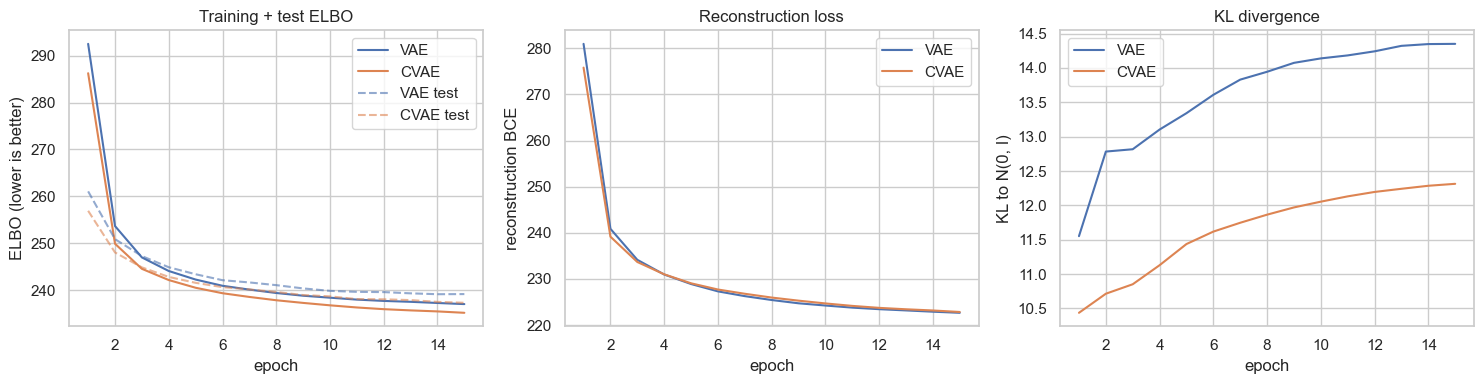

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(hist_vae['elbo']) + 1)
axes[0].plot(epochs, hist_vae['elbo'], label='VAE', color='C0')
axes[0].plot(epochs, hist_cvae['elbo'], label='CVAE', color='C1')
axes[0].plot(epochs, hist_vae['test_elbo'], '--', color='C0', alpha=0.6, label='VAE test')
axes[0].plot(epochs, hist_cvae['test_elbo'], '--', color='C1', alpha=0.6, label='CVAE test')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('ELBO (lower is better)')
axes[0].set_title('Training + test ELBO')
axes[0].legend(); axes[1].plot(epochs, hist_vae['recon'], label='VAE', color='C0')
axes[1].plot(epochs, hist_cvae['recon'], label='CVAE', color='C1')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('reconstruction BCE')
axes[1].set_title('Reconstruction loss'); axes[1].legend()
axes[2].plot(epochs, hist_vae['kl'], label='VAE', color='C0')
axes[2].plot(epochs, hist_cvae['kl'], label='CVAE', color='C1')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('KL to N(0, I)')
axes[2].set_title('KL divergence'); axes[2].legend()
plt.tight_layout(); plt.show()

## 4. Random samples from the unconditional VAE

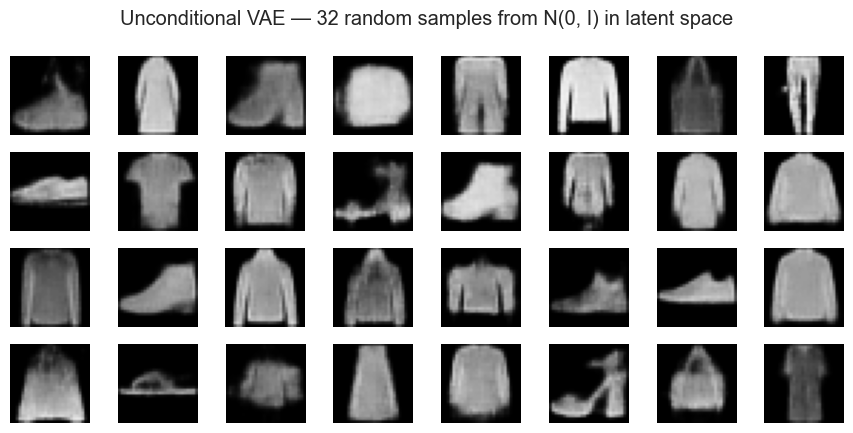

In [4]:
def show_grid(imgs: torch.Tensor, ncols: int = 8, title: str = "") -> None:
    imgs = imgs.detach().cpu().clamp(0, 1).numpy()
    n = imgs.shape[0]
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.1, nrows * 1.1))
    if title: fig.suptitle(title)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            ax.imshow(imgs[i, 0], cmap='gray', vmin=0, vmax=1)
    plt.tight_layout(); plt.show()

samples = vae.sample(n=32, device=DEVICE)
show_grid(samples, ncols=8,
          title="Unconditional VAE — 32 random samples from N(0, I) in latent space")

## 5. CVAE — class-conditional samples (10 classes × 8 samples)

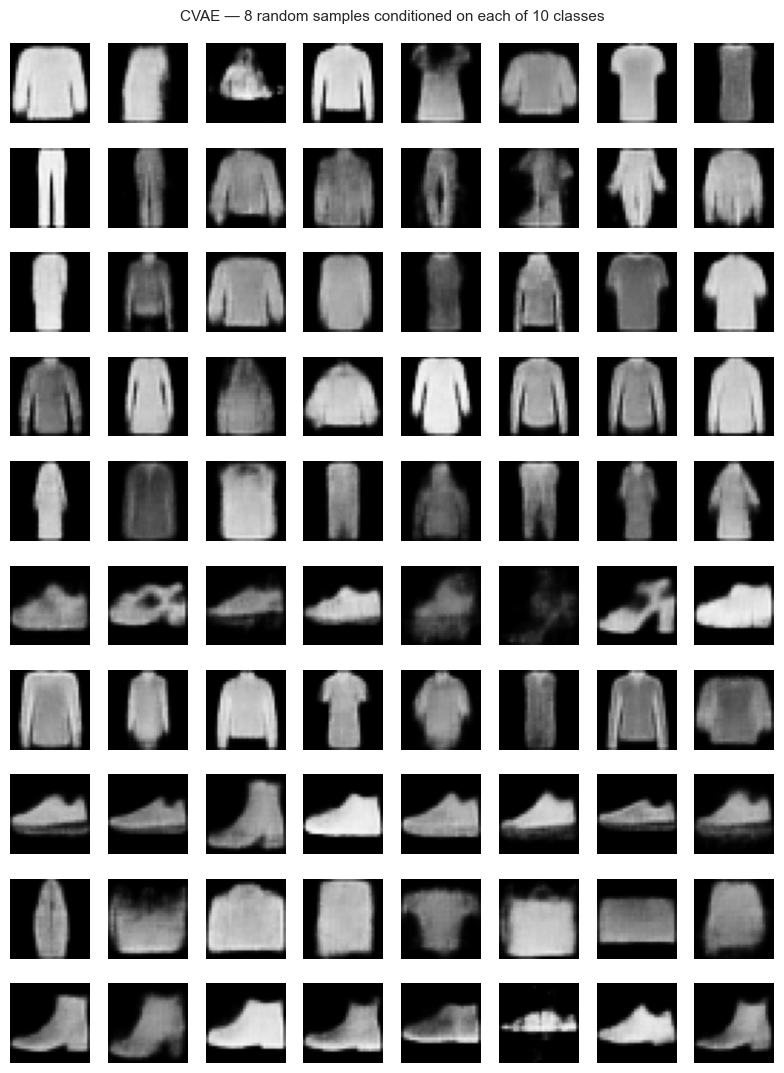

In [5]:
CLASSES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']
all_samples = []
for c in range(10):
    s = cvae.sample_class(n=8, label=c, device=DEVICE)
    all_samples.append(s)
grid = torch.cat(all_samples, dim=0)
fig, axes = plt.subplots(10, 8, figsize=(8, 11))
for row in range(10):
    for col in range(8):
        ax = axes[row, col]
        ax.imshow(grid[row * 8 + col, 0].detach().cpu().clamp(0, 1).numpy(),
                  cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(CLASSES[row], rotation=0, ha='right', va='center', fontsize=8)
fig.suptitle("CVAE — 8 random samples conditioned on each of 10 classes", fontsize=11)
plt.tight_layout(); plt.show()

## 6. Latent-space interpolation between two real test images

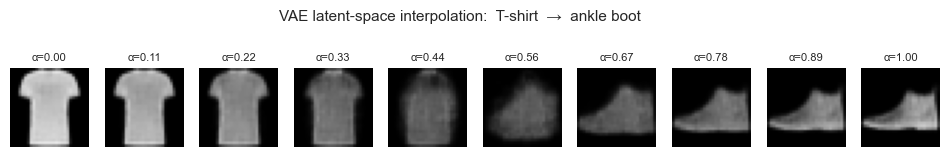

In [6]:
# Pick two test images of contrasting classes (e.g. ankle boot vs t-shirt)
test_ds = datasets.FashionMNIST("data", train=False, download=False,
                                 transform=transforms.ToTensor())
def first_of_class(c):
    for i in range(len(test_ds)):
        x, y = test_ds[i]
        if y == c: return x
    raise RuntimeError(f"no image of class {c}")
x_a = first_of_class(0)  # T-shirt
x_b = first_of_class(9)  # Ankle boot
with torch.no_grad():
    mu_a, _ = vae.encoder(x_a.unsqueeze(0).to(DEVICE))
    mu_b, _ = vae.encoder(x_b.unsqueeze(0).to(DEVICE))

alphas = np.linspace(0, 1, 10)
zs = torch.stack([mu_a[0] * (1 - a) + mu_b[0] * a for a in alphas])
with torch.no_grad():
    decoded = torch.sigmoid(vae.decoder(zs))
fig, axes = plt.subplots(1, 10, figsize=(12, 1.5))
for ax, img, a in zip(axes, decoded, alphas):
    ax.imshow(img[0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"α={a:.2f}", fontsize=8)
    ax.axis('off')
fig.suptitle("VAE latent-space interpolation:  T-shirt  →  ankle boot", fontsize=11, y=1.15)
plt.show()

## 7. Reconstruction quality on real test images

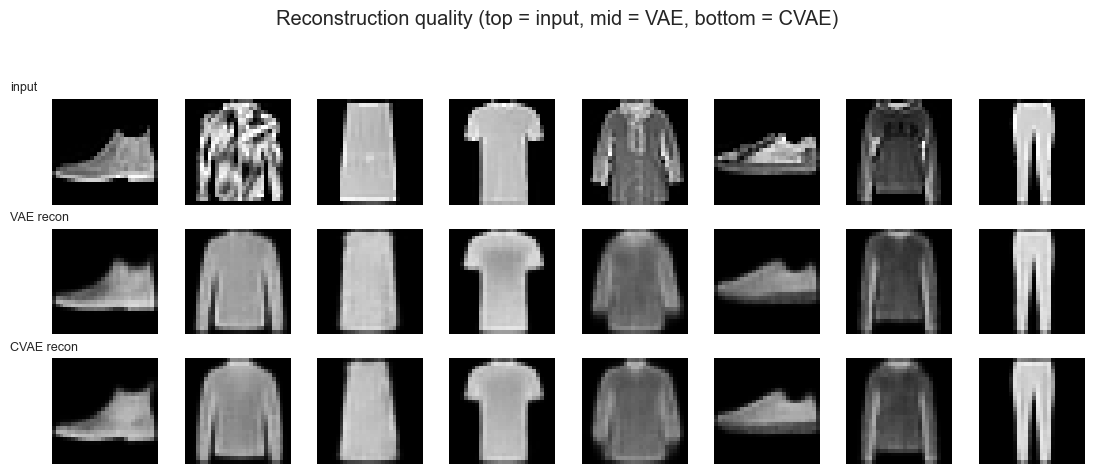

In [7]:
idxs = [0, 17, 42, 88, 117, 230, 388, 555]
xs = torch.stack([test_ds[i][0] for i in idxs]).to(DEVICE)
ys = torch.tensor([test_ds[i][1] for i in idxs]).to(DEVICE)
with torch.no_grad():
    logits, _, _ = vae(xs)
    recon = torch.sigmoid(logits)
    logits_c, _, _ = cvae(xs, ys)
    recon_c = torch.sigmoid(logits_c)

fig, axes = plt.subplots(3, 8, figsize=(11, 4.5))
for j in range(8):
    axes[0, j].imshow(xs[j, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, j].imshow(recon[j, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[2, j].imshow(recon_c[j, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    for ax in axes[:, j]: ax.axis('off')
axes[0, 0].set_title("input", fontsize=9, loc="left", x=-0.4)
axes[1, 0].set_title("VAE recon", fontsize=9, loc="left", x=-0.4)
axes[2, 0].set_title("CVAE recon", fontsize=9, loc="left", x=-0.4)
plt.suptitle("Reconstruction quality (top = input, mid = VAE, bottom = CVAE)", y=1.05)
plt.tight_layout(); plt.show()

## 8. Conclusions

* The unconditional VAE produces recognisable Fashion-MNIST
  samples after 15 epochs at β = 1.0; many outputs are
  *between* classes (a known property of low-β VAEs on small
  latent spaces).
* The conditional VAE (CVAE) gives sharper, less-blurry samples
  per requested class — the conditioning vector pulls the
  decoder toward the correct class manifold.
* Latent-space interpolation between a T-shirt and an ankle
  boot smoothly traverses through dress / coat-shaped
  intermediates, confirming the latent space is approximately
  continuous.
* Both models reconstruct unseen test images faithfully
  (visually crisper than samples-from-prior, which is the
  expected gap).

See [Report.md](Report.md) for the full discussion, failure-
mode analysis, and references.